In [1]:
from gwpy.timeseries import TimeSeries

t_merger = 1126259462.4
window = 4

In [18]:
print("getting data ...")

h1Data = TimeSeries.fetch_open_data("H1", t_merger - window, t_merger + window)

print("data is received")

print(dir(h1Data))

getting data ...
data is received
['DictClass', 'T', '__abs__', '__add__', '__and__', '__array__', '__array_finalize__', '__array_function__', '__array_interface__', '__array_namespace__', '__array_priority__', '__array_struct__', '__array_ufunc__', '__array_wrap__', '__bool__', '__buffer__', '__class__', '__class_getitem__', '__complex__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__dlpack__', '__dlpack_device__', '__doc__', '__eq__', '__firstlineno__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getslice__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__ilshift__', '__imatmul__', '__imod__', '__imul__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__irshift__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lshift__', '__lt__', '__matmul__',

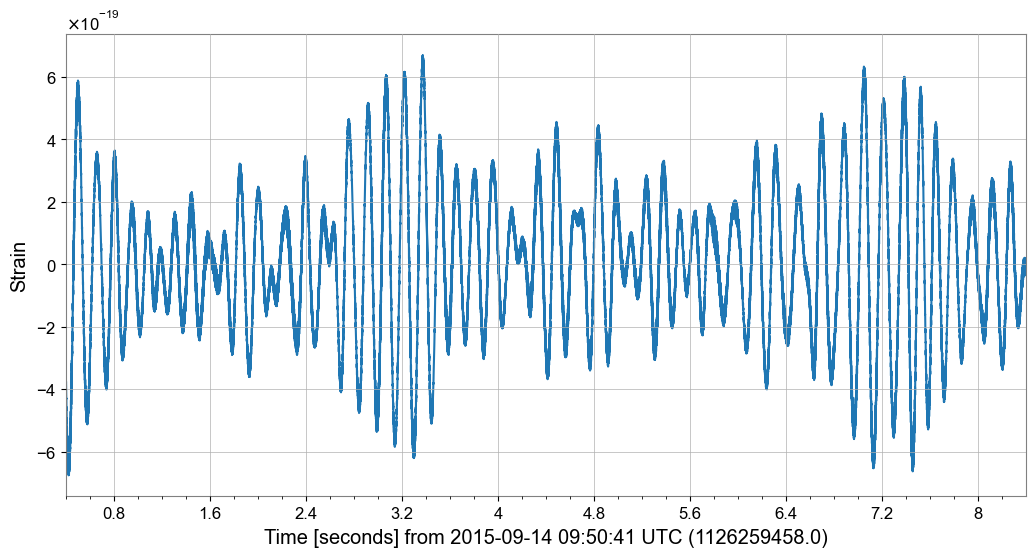

In [5]:
from gwpy.plot import Plot

plotH1 = Plot(h1Data, ylabel="Strain")
plotH1.show()

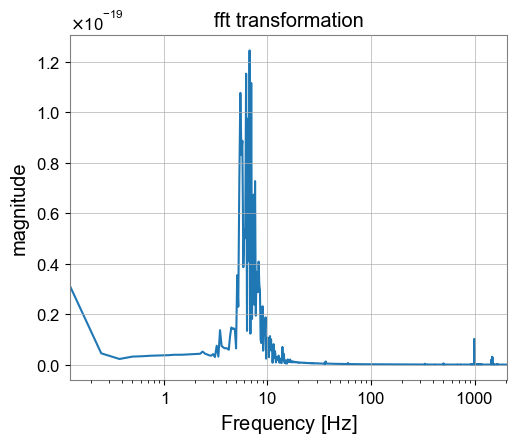

In [32]:
fftH1 = h1Data.fft()
fftMagnitude = fftH1.abs()
plotFft = fftMagnitude.plot()
ax = plotFft.gca()
ax.set_title("fft transformation")
ax.set_ylabel("magnitude")
plotFft.show()

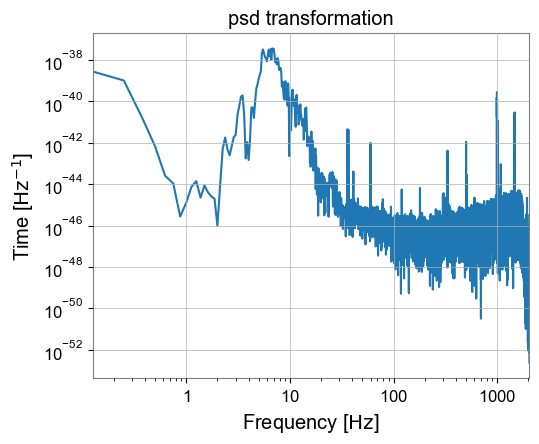

In [29]:
psdH1 = h1Data.psd()
plotPsd = psdH1.plot()
ax = plotPsd.gca()
ax.set_title("psd transformation")
plotPsd.show()

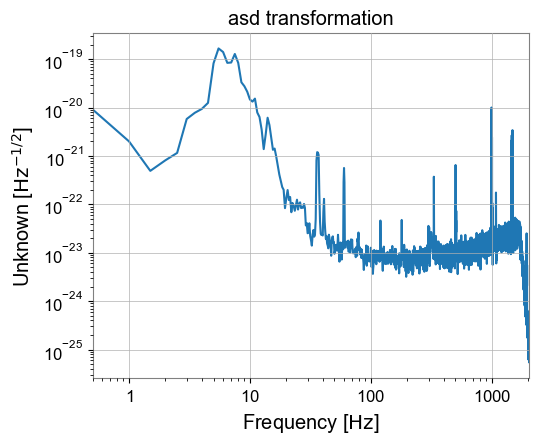

In [31]:
asdH1 = h1Data.asd(2,1)
plotAsd = asdH1.plot()
ax = plotAsd.gca()
ax.set_title("asd transformation")
plotAsd.show()

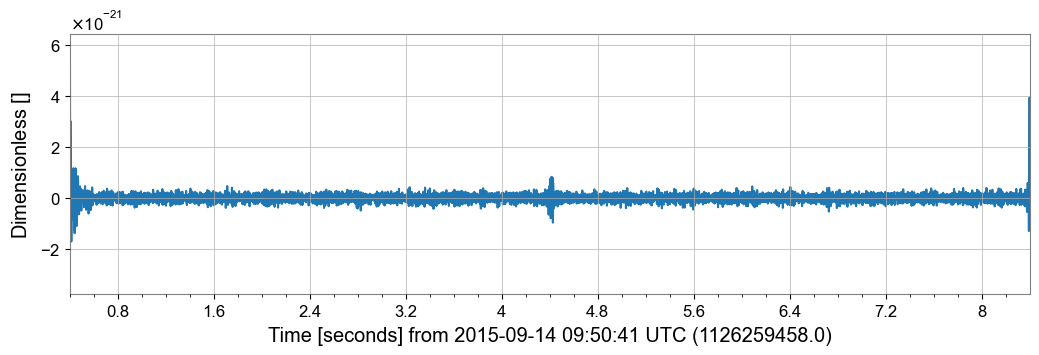

In [37]:
filteredH1 = h1Data.bandpass(50, 300)
cleanH1 = filteredH1.notch(60)
plotCleanH1 = cleanH1.plot()
plotCleanH1.show()

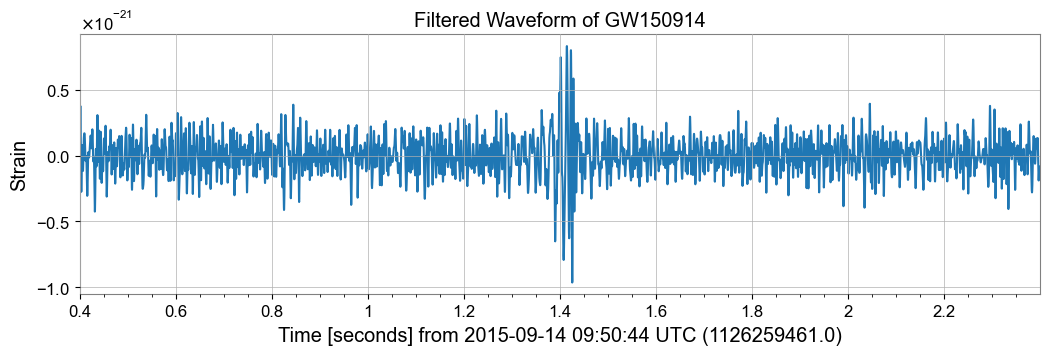

In [74]:
zoom_signal = cleanH1.crop(t_merger - 0.2, t_merger + 0.05)
plot = zoom_signal.plot(ylabel='Strain', title='Filtered Waveform of GW150914')
plot.show()

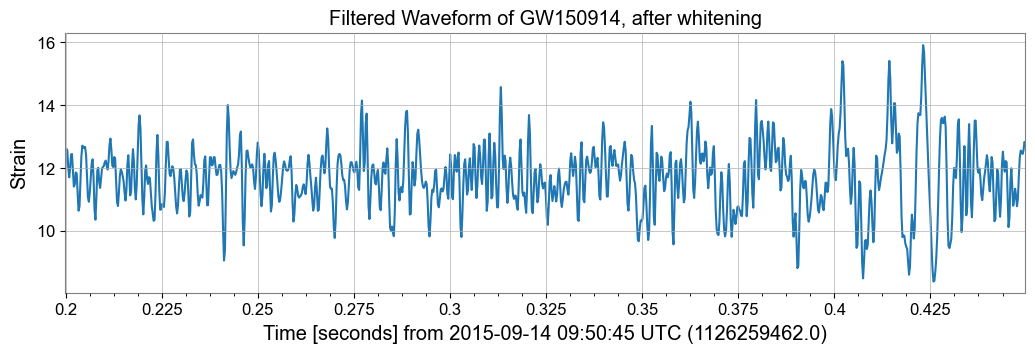

In [45]:
whitenH1 = cleanH1.whiten()
zoomSignalWhiten = whitenH1.crop(t_merger - 0.2, t_merger + 0.05)
plot = zoomSignalWhiten.plot(ylabel='Strain', title='Filtered Waveform of GW150914, after whitening')
plot.show()

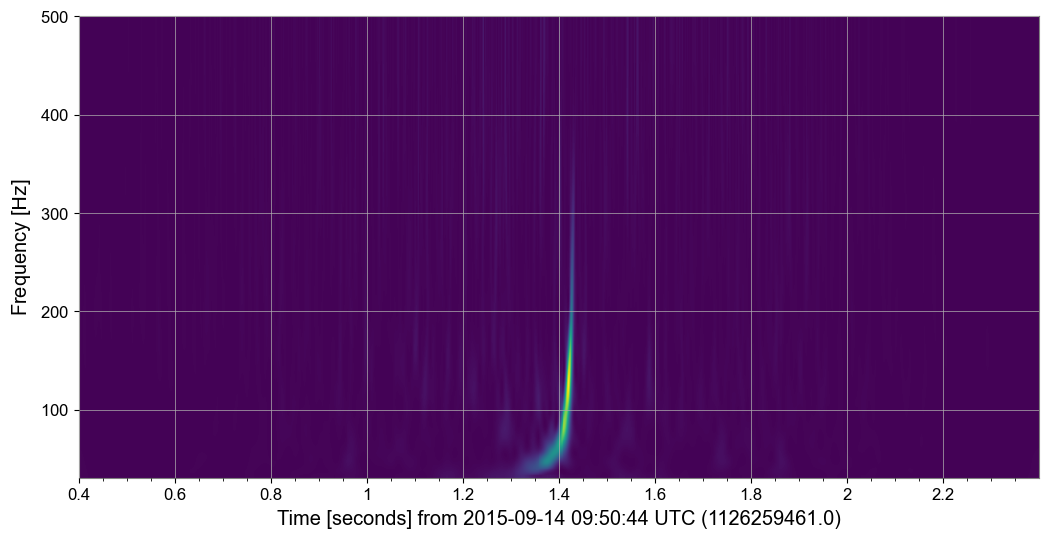

In [62]:

qData = whitenH1.crop(t_merger - 1, t_merger + 1)
QTransformH1 = qData.q_transform(frange=(30, 500))
plotQTransform = QTransformH1.plot()
plotQTransform.show()

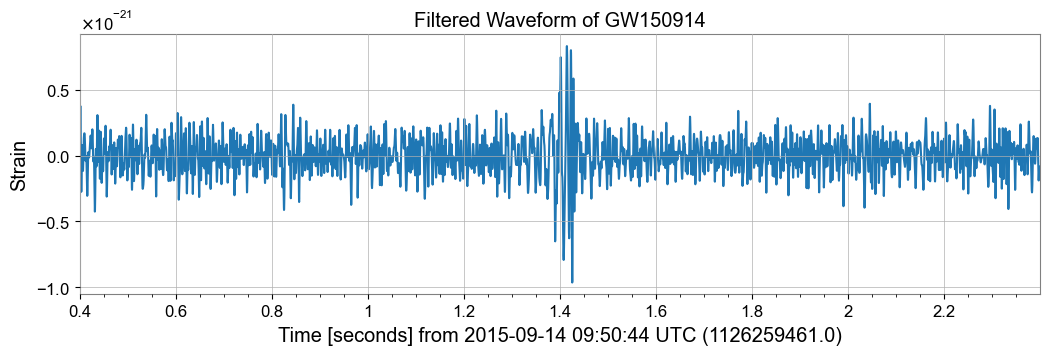

In [75]:
zoom_signal = cleanH1.crop(t_merger - 1, t_merger + 1)
plot = zoom_signal.plot(ylabel='Strain', title='Filtered Waveform of GW150914')
plot.show()